In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', None)

In [2]:
df = pd.read_csv('supportTicketData.csv')
df

,TicketID,Ticket detailed description,urgency-Priority
0,123456,connection issues with assigned address hi facing connection issues number en tried changing cable switch with working ones works for colleagues machine still luck problem must be with address if change works can you please assist further thank you,P1
1,123457,cannot access hi cannot access fallowing link get blank cannot proceed can you please help with thanks,P2
2,123458,re address shown valid dear colleagues remarked name written wrong could you please be change thank you compliance officer frankfurt main frankfurt main sent address shown valid dear colleagues could you please check why we have issues with address for we had yesterday same issue with another colleague thank you compliance officer frankfurt main frankfurt main sent welcome hi can you please check what going with address please print screen below sent thursday undeliverable welcome failed these or groups address you entered be found please check recipient address try message if problem continues please contact your diagnostic information for administrators generating server remote server returned resolver found original message headers with server id with id content type application name content transfer encoding binary welcome thread topic welcome thread index calendar originator id be date message id accept language en en content language en attach mime version transport hosted originating return path,P1
3,123459,sent tuesday critical alert following alert occurred status active data source type data source computer server description last recovery points created unexpected error occurred while job was running for more information open administrator console review alert details monitoring task area,P2
4,123460,code spelling mistake hello should discover for code please can you change thanks head,P2
...,...,...,...
19791,143247,hello two broken fuses monitor cable has helped these things thank,P3
19792,143248,rights hi want add developer repository cannot him think must add him user thank senior architect,P3
19793,143249,wang,P3
19794,143250,hello today take equipment otherwise leaving equipment display mouse headset floor thank,P3


### understanding data frame 1 named as df

In [3]:
df.shape

(19796, 3)

In [4]:
df.head(5)

,TicketID,Ticket detailed description,urgency-Priority
0,123456,connection issues with assigned address hi facing connection issues number en tried changing cable switch with working ones works for colleagues machine still luck problem must be with address if change works can you please assist further thank you,P1
1,123457,cannot access hi cannot access fallowing link get blank cannot proceed can you please help with thanks,P2
2,123458,re address shown valid dear colleagues remarked name written wrong could you please be change thank you compliance officer frankfurt main frankfurt main sent address shown valid dear colleagues could you please check why we have issues with address for we had yesterday same issue with another colleague thank you compliance officer frankfurt main frankfurt main sent welcome hi can you please check what going with address please print screen below sent thursday undeliverable welcome failed these or groups address you entered be found please check recipient address try message if problem continues please contact your diagnostic information for administrators generating server remote server returned resolver found original message headers with server id with id content type application name content transfer encoding binary welcome thread topic welcome thread index calendar originator id be date message id accept language en en content language en attach mime version transport hosted originating return path,P1
3,123459,sent tuesday critical alert following alert occurred status active data source type data source computer server description last recovery points created unexpected error occurred while job was running for more information open administrator console review alert details monitoring task area,P2
4,123460,code spelling mistake hello should discover for code please can you change thanks head,P2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19796 entries, 0 to 19795
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   TicketID                     19796 non-null  int64 
 1   Ticket detailed description  19796 non-null  object
 2   urgency-Priority             19796 non-null  object
dtypes: int64(1), object(2)
memory usage: 464.1+ KB


In [6]:
df.columns

Index(['TicketID', 'Ticket detailed description', 'urgency-Priority'], dtype='object')

In [7]:
df.isna().sum()

TicketID                       0
Ticket detailed description    0
urgency-Priority               0
dtype: int64

In [8]:
df_final = df.rename(columns={
    'Ticket detailed description': 'description',
    'urgency-Priority': 'priority'
})

In [9]:
df_final.drop('TicketID',axis =1 , inplace =True)

In [10]:
ticket_priority_dist = df_final['priority'].value_counts(normalize = True)*100
ticket_priority_dist

priority
P3    37.987472
P1    34.087694
P2    27.924833
Name: proportion, dtype: float64

In [11]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19796 entries, 0 to 19795
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   description  19796 non-null  object
 1   priority     19796 non-null  object
dtypes: object(2)
memory usage: 309.4+ KB


In [12]:
df_final['description']

0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         connection issues with assigned address hi facing connection issues number en tried changing cable switch with working ones works for colleagues machine still luck problem must be with address if change works can you pleas

In [13]:
df_final['description'].head(3)

0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     connection issues with assigned address hi facing connection issues number en tried changing cable switch with working ones works for colleagues machine still luck problem must be with address if change works can you please as

In [14]:
df_final['desc_len'] = df_final['description'].str.len()
df_final

,description,priority,desc_len
0,connection issues with assigned address hi facing connection issues number en tried changing cable switch with working ones works for colleagues machine still luck problem must be with address if change works can you please assist further thank you,P1,248
1,cannot access hi cannot access fallowing link get blank cannot proceed can you please help with thanks,P2,102
2,re address shown valid dear colleagues remarked name written wrong could you please be change thank you compliance officer frankfurt main frankfurt main sent address shown valid dear colleagues could you please check why we have issues with address for we had yesterday same issue with another colleague thank you compliance officer frankfurt main frankfurt main sent welcome hi can you please check what going with address please print screen below sent thursday undeliverable welcome failed these or groups address you entered be found please check recipient address try message if problem continues please contact your diagnostic information for administrators generating server remote server returned resolver found original message headers with server id with id content type application name content transfer encoding binary welcome thread topic welcome thread index calendar originator id be date message id accept language en en content language en attach mime version transport hosted originating return path,P1,1017
3,sent tuesday critical alert following alert occurred status active data source type data source computer server description last recovery points created unexpected error occurred while job was running for more information open administrator console review alert details monitoring task area,P2,290
4,code spelling mistake hello should discover for code please can you change thanks head,P2,86
...,...,...,...
19791,hello two broken fuses monitor cable has helped these things thank,P3,66
19792,rights hi want add developer repository cannot him think must add him user thank senior architect,P3,97
19793,wang,P3,4
19794,hello today take equipment otherwise leaving equipment display mouse headset floor thank,P3,88


In [15]:
df_final[['desc_len']].describe()

,desc_len
count,19796.000000
mean,293.695848
std,414.341088
min,2.000000
25%,100.000000
50%,171.000000
75%,302.000000
max,7011.000000


In [16]:
ticket_priority = df_final['priority'].value_counts(normalize = True)*100
ticket_priority

priority
P3    37.987472
P1    34.087694
P2    27.924833
Name: proportion, dtype: float64

[]

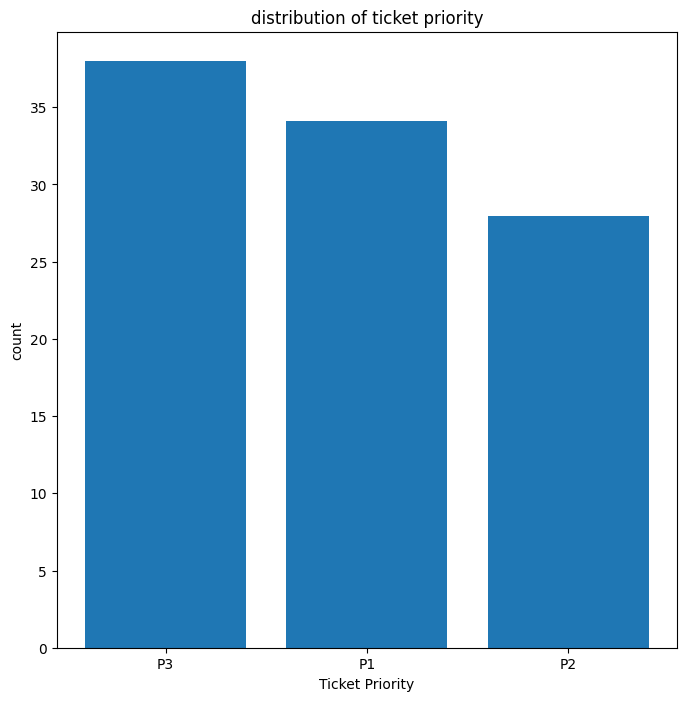

In [17]:
plt.figure(figsize = (8,8))
plt.bar(ticket_priority.index , ticket_priority.values)
plt.xlabel('Ticket Priority') 
plt.ylabel('count')
plt.title("distribution of ticket priority")
plt.plot()

[]

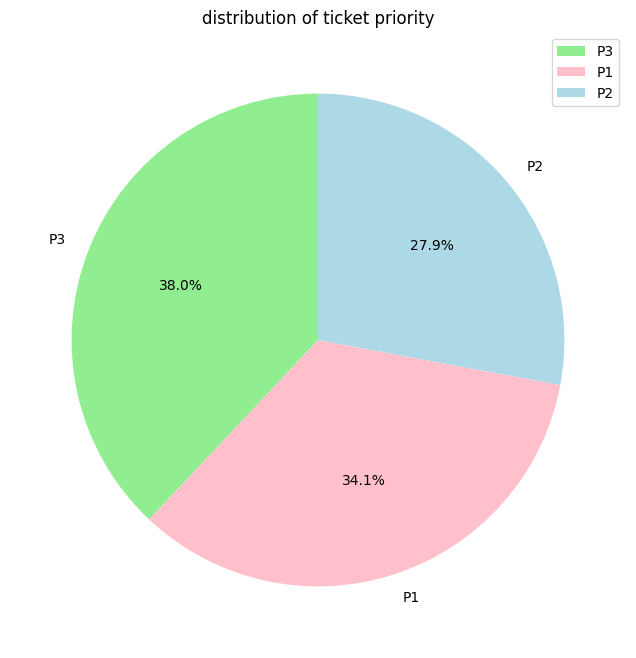

In [18]:
plt.figure(figsize = (8,8))
plt.pie( ticket_priority.values , labels = ticket_priority.index ,colors =['lightgreen','pink','lightblue','lavender'] , autopct = '%1.1f%%',startangle=90)
plt.legend()

plt.title("distribution of ticket priority")
plt.plot()

In [19]:
df_final['description'].duplicated().sum()

np.int64(0)

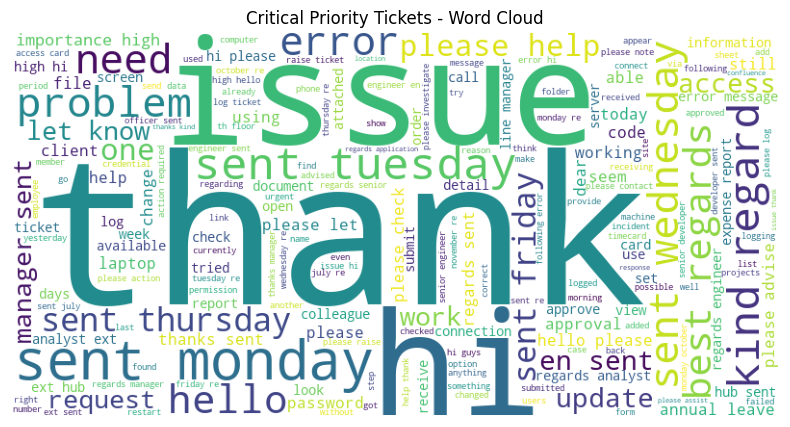

In [20]:
from wordcloud import WordCloud
P1_description = " ".join(
    df_final[df_final['priority'] == 'P1']['description']
)

wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=None
)

wc.generate(P1_description)

plt.figure(figsize=(10,5))
plt.imshow(wc.to_image())
plt.axis('off')
plt.title("Critical Priority Tickets - Word Cloud")
plt.show()


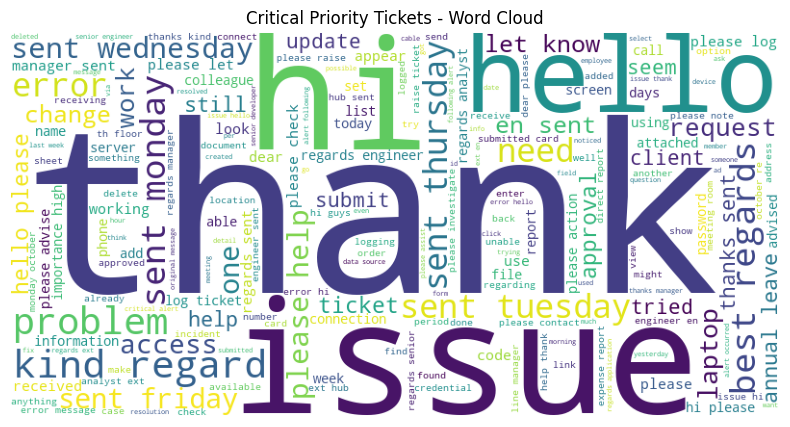

In [21]:
from wordcloud import WordCloud
p2_description = " ".join(
    df_final[df_final['priority'] == 'P2']['description']
)

wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=None
)

wc.generate(p2_description)

plt.figure(figsize=(10,5))
plt.imshow(wc.to_image())
plt.axis('off')
plt.title("Critical Priority Tickets - Word Cloud")
plt.show()


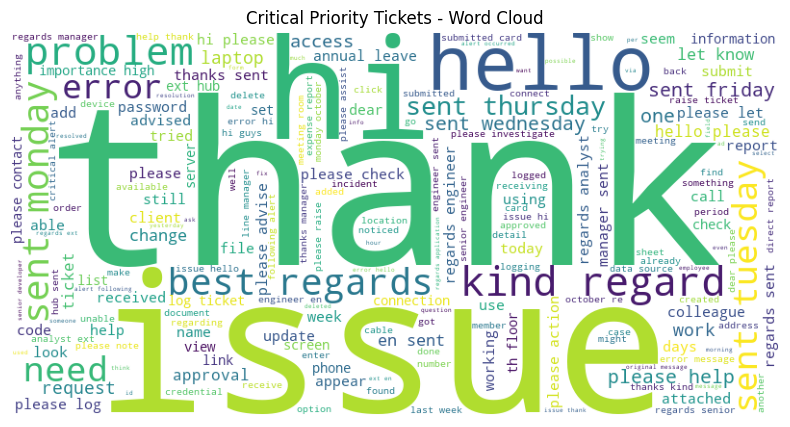

In [22]:
from wordcloud import WordCloud
P2_description = " ".join(
    df_final[df_final['priority'] == 'P2']['description']
)

wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=None
)

wc.generate(P2_description)

plt.figure(figsize=(10,5))
plt.imshow(wc.to_image())
plt.axis('off')
plt.title("Critical Priority Tickets - Word Cloud")
plt.show()


In [23]:
import nltk
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))


In [24]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

import re
def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()

    text = re.sub(r"\{.*?\}", "", text)

    text = re.sub(r"http\S+|www\S+", "", text)

    text = re.sub(r"[^a-z\s]", "", text)
    
    words = text.split(' ')
    words = [ lemmatizer.lemmatize(word) for word in words if word not in stop_words and len(word) > 2 ]
    
    return " ".join(words)


In [25]:
df_final['clean_text'] = df_final['description'].apply(clean_text)

In [26]:
df_final.drop('description',axis = 1 , inplace = True)

In [27]:
df_final.head(1)


,priority,desc_len,clean_text
0,P1,248,connection issue assigned address facing connection issue number tried changing cable switch working one work colleague machine still luck problem must address change work please assist thank


In [28]:
from sklearn.model_selection import train_test_split

X = df_final['clean_text']
y = df_final['priority']

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,      # top 5k important words
    ngram_range=(1,2),     
    min_df=2                
)

In [30]:
x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

In [31]:
print(x_train_tfidf.shape)


(15836, 5000)


In [32]:
tfidf.get_feature_names_out()[:20]

array(['ability', 'able', 'able access', 'able add', 'able approve',
       'able connect', 'able find', 'able help', 'able log', 'able open',
       'able submit', 'able use', 'absence', 'absence leave',
       'absence location', 'absence record', 'accept', 'accept decline',
       'accept language', 'accept liability'], dtype=object)

In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)


In [34]:
dict(zip(le.classes_, le.transform(le.classes_)))


{'P1': np.int64(0), 'P2': np.int64(1), 'P3': np.int64(2)}

In [35]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',   
    n_jobs=1
)


In [36]:
log_reg.fit(x_train_tfidf, y_train_enc)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [37]:
y_pred_lr = log_reg.predict(x_test_tfidf)


In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test_enc, y_pred_lr, target_names=le.classes_))


              precision    recall  f1-score   support

          P1       0.69      0.67      0.68      1350
          P2       0.60      0.58      0.59      1106
          P3       0.94      0.98      0.96      1504

    accuracy                           0.76      3960
   macro avg       0.74      0.74      0.74      3960
weighted avg       0.76      0.76      0.76      3960



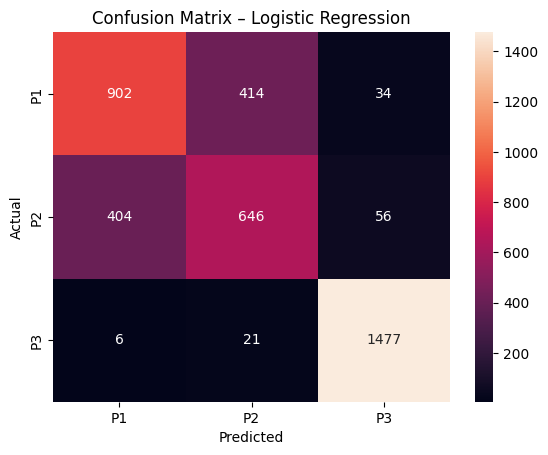

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_enc, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Logistic Regression")
plt.show()


In [40]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test_enc, y_pred_lr)*100

76.38888888888889

In [41]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB(
    alpha=0.5   # smoothing (important)
)


In [42]:
nb_model.fit(x_train_tfidf, y_train_enc)


,alpha,0.5
,force_alpha,True
,fit_prior,True
,class_prior,None


In [43]:
y_pred_nb = nb_model.predict(x_test_tfidf)


In [44]:
accuracy_score(y_test_enc, y_pred_nb)*100

73.35858585858585

In [45]:
print(classification_report(
    y_test_enc,
    y_pred_nb,
    target_names=le.classes_)
     )

              precision    recall  f1-score   support

          P1       0.61      0.81      0.69      1350
          P2       0.61      0.37      0.46      1106
          P3       0.95      0.93      0.94      1504

    accuracy                           0.73      3960
   macro avg       0.72      0.70      0.70      3960
weighted avg       0.74      0.73      0.72      3960



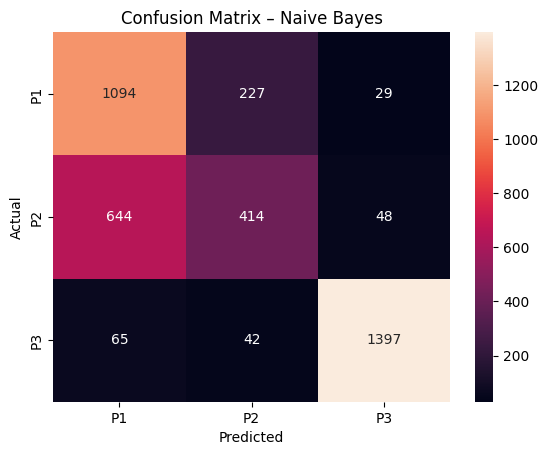

In [46]:
cm = confusion_matrix(y_test_enc, y_pred_nb)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Naive Bayes")
plt.show()

In [48]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    objective='multi:softmax',   # multi-class classification
    num_class= 3 ,  # 3 hamre case m 
    n_estimators=100,
    max_depth=6,
    learning_rate=0.15,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=1,
    n_jobs=-1
)

In [49]:
xgb_model.fit(x_train_tfidf, y_train_enc)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [50]:
y_pred_xgb = xgb_model.predict(x_test_tfidf)


In [51]:
accuracy_score(y_test_enc, y_pred_xgb)*100

75.4040404040404

# cross validation using GridSearchCC

In [52]:
# Grid Search CV for Logistic_regresssion_one_vs_rest model
from sklearn.model_selection import GridSearchCV

log_reg_ovr = LogisticRegression(
    max_iter=3000,
    class_weight='balanced',
    multi_class = 'ovr'
    
)

param_grid_lr = {
    'C': [0.1, 0.5, 1, 2, 5],
    'solver': ['lbfgs', 'saga']
}

grid_lr_ovr = GridSearchCV(
    estimator=log_reg_ovr,
    param_grid=param_grid_lr,
    scoring='f1_macro',   # IMPORTANT for imbalance
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_lr_ovr.fit(x_train_tfidf, y_train_enc)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,LogisticRegre...i_class='ovr')
,param_grid,"{'C': [0.1, 0.5, ...], 'solver': ['lbfgs', 'saga']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [53]:
print("Best Params (LR):", grid_lr_ovr.best_params_)
print("Best CV Score (LR):", grid_lr_ovr.best_score_*100)

Best Params (LR): {'C': 1, 'solver': 'saga'}
Best CV Score (LR): 72.19154624946833


In [54]:
final_lr_ovr_model = grid_lr_ovr.best_estimator_
final_lr_ovr_model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'saga'
,max_iter,3000
,multi_class,'ovr'


In [ ]:
y_pred_lr_ovr = final_lr_ovr_model.predict(x_test_tfidf)
print(f"test accuracy for ovr model is {accuracy_score(y_test_enc,y_pred_lr_ovr)*100:.2f}")

test accuracy for ovr model is 75.88


In [56]:
print(classification_report(
    y_test_enc,
    y_pred_lr_ovr,
    target_names=le.classes_
))

              precision    recall  f1-score   support

          P1       0.67      0.70      0.69      1350
          P2       0.61      0.53      0.56      1106
          P3       0.92      0.98      0.95      1504

    accuracy                           0.76      3960
   macro avg       0.73      0.74      0.73      3960
weighted avg       0.75      0.76      0.75      3960



In [57]:
log_reg_multinomial = LogisticRegression(
    max_iter=3000,
    class_weight='balanced',
    multi_class = 'multinomial'
    
)


grid_lr_multinomial = GridSearchCV(
    estimator=log_reg_multinomial,
    param_grid=param_grid_lr,
    scoring='f1_macro',   # IMPORTANT for imbalance
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_lr_multinomial.fit(x_train_tfidf, y_train_enc)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,LogisticRegre...'multinomial')
,param_grid,"{'C': [0.1, 0.5, ...], 'solver': ['lbfgs', 'saga']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [58]:
print("Best Params (LR):", grid_lr_multinomial.best_params_)
print("Best CV Score (LR):", grid_lr_multinomial.best_score_*100)

Best Params (LR): {'C': 1, 'solver': 'saga'}
Best CV Score (LR): 72.31069867247004


In [59]:
final_lr_multinomial_model = grid_lr_multinomial.best_estimator_
final_lr_multinomial_model
y_pred_lr_multinomial = final_lr_multinomial_model.predict(x_test_tfidf)
print(f"test accuracy for multinomial model is {accuracy_score(y_test_enc,y_pred_lr_multinomial)*100:.2f}")

test accuracy for multinomial model is 76.49


In [60]:
print(classification_report(
    y_test_enc,
    y_pred_lr_multinomial,
    target_names=le.classes_
))

              precision    recall  f1-score   support

          P1       0.69      0.67      0.68      1350
          P2       0.60      0.58      0.59      1106
          P3       0.94      0.98      0.96      1504

    accuracy                           0.76      3960
   macro avg       0.74      0.75      0.74      3960
weighted avg       0.76      0.76      0.76      3960



In [61]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV

nb = MultinomialNB()

param_grid_nb = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]
}

grid_nb = GridSearchCV(
    estimator=nb,
    param_grid=param_grid_nb,
    scoring='f1_macro',
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_nb.fit(x_train_tfidf, y_train_enc)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,estimator,MultinomialNB()
,param_grid,"{'alpha': [0.01, 0.1, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.01


In [62]:
print("Best Params for naive bayes :", grid_nb.best_params_)
print("Best CV Score naive bays:", grid_nb.best_score_*100)

Best Params for naive bayes : {'alpha': 0.01}
Best CV Score naive bays: 70.00172739330385


In [63]:
final_nb_model = grid_nb.best_estimator_
final_nb_model

,alpha,0.01
,force_alpha,True
,fit_prior,True
,class_prior,None


In [64]:
y_pred_nb_best = final_nb_model.predict(x_test_tfidf)
print(f"test accuracy for naive_bayes model is {accuracy_score(y_test_enc,y_pred_nb_best)*100:.2f}")

test accuracy for naive_bayes model is 73.21


In [65]:
print(classification_report(
    y_test_enc,
    y_pred_nb_best,
    target_names=le.classes_
))

              precision    recall  f1-score   support

          P1       0.60      0.78      0.68      1350
          P2       0.59      0.41      0.48      1106
          P3       0.96      0.92      0.94      1504

    accuracy                           0.73      3960
   macro avg       0.72      0.71      0.70      3960
weighted avg       0.74      0.73      0.73      3960



In [66]:
xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    random_state=1,
    n_jobs=-1
)
from sklearn.model_selection import RandomizedSearchCV

param_dist_xgb = {
    'n_estimators': [120,220],
    'max_depth': [5,7],
    'learning_rate': [0.1],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.8]
}
random_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=10,                 # number of random combinations we are using ( not like grid search jaha har ek combinition check hota tha )
    scoring='f1_macro',
    cv=3,
    verbose=2,
    random_state=1,
    n_jobs=-1
)
random_xgb.fit(x_train_tfidf, y_train_enc)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,estimator,"XGBClassifier..._class=3, ...)"
,param_distributions,"{'colsample_bytree': [0.8], 'learning_rate': [0.1], 'max_depth': [5, 7], 'n_estimators': [120, 220], ...}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,1
,error_score,nan


In [67]:
print("Best Params for XG_BOOST :", random_xgb.best_params_)
print("Best CV Score XG_BOOST :", random_xgb.best_score_*100)

Best Params for XG_BOOST : {'subsample': 0.7, 'n_estimators': 220, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV Score XG_BOOST : 72.15436002615311


In [68]:
final_xgb_model = random_xgb.best_estimator_
y_pred_xgb = final_xgb_model.predict(x_test_tfidf)
print(f"test accuracy for finalX GBOOST from randomisedsearch cv model is {accuracy_score(y_test_enc,y_pred_xgb)*100:.2f}")

test accuracy for finalX GBOOST from randomisedsearch cv model is 75.58


In [69]:
print(classification_report(
    y_test_enc,
    y_pred_xgb,
    target_names=le.classes_
))

              precision    recall  f1-score   support

          P1       0.66      0.75      0.70      1350
          P2       0.62      0.45      0.52      1106
          P3       0.92      0.99      0.95      1504

    accuracy                           0.76      3960
   macro avg       0.73      0.73      0.72      3960
weighted avg       0.75      0.76      0.75      3960



In [97]:
print(f"best prams for finalX GBOOST from randomisedsearch cv model is {final_xgb_model.get_params}")
print(f"best prams for best naive_bayes model from grid search cv is {final_nb_model.get_params}")
print(f"best prams for best multinomial model from grid search cv is {final_lr_multinomial_model.get_params}")
print(f"best prams for best one vs rest model from grid search cv is {final_lr_ovr_model.get_params}")

best prams for finalX GBOOST from randomisedsearch cv model is <bound method XGBModel.get_params of XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=220, n_jobs=-1, num_class=3, ...)>
best prams for best naive_bayes model from grid search cv is <bound method BaseEstimator.get_params of MultinomialNB(alpha=0.01)>
best prams for best m

In [70]:
print(f"test accuracy for finalX GBOOST from randomisedsearch cv model is {accuracy_score(y_test_enc,y_pred_xgb)*100:.2f}")
print(f"test accuracy for best naive_bayes model from grid search cv is {accuracy_score(y_test_enc,y_pred_nb_best)*100:.2f}")
print(f"test accuracy for best multinomial model from grid search cv is {accuracy_score(y_test_enc,y_pred_lr_multinomial)*100:.2f}")
print(f"test accuracy for best one vs rest model from grid search cv is {accuracy_score(y_test_enc,y_pred_lr_ovr)*100:.2f}")

test accuracy for finalX GBOOST from randomisedsearch cv model is 75.58
test accuracy for best naive_bayes model from grid search cv is 73.21
test accuracy for best multinomial model from grid search cv is 76.49
test accuracy for best one vs rest model from grid search cv is 75.88


In [90]:
import pickle
import os

MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

with open(os.path.join(MODEL_DIR, "ovr_log_reg.pkl"), "wb") as f:
    pickle.dump(final_lr_ovr_model, f)

with open(os.path.join(MODEL_DIR, "multinomial_log_reg.pkl"), "wb") as f:
    pickle.dump(final_lr_multinomial_model, f)

with open(os.path.join(MODEL_DIR, "naive_bayes.pkl"), "wb") as f:
    pickle.dump(final_nb_model, f)

with open(os.path.join(MODEL_DIR, "xgboost.pkl"), "wb") as f:
    pickle.dump(final_xgb_model, f)

with open(os.path.join(MODEL_DIR, "tfidf.pkl"), "wb") as f:
    pickle.dump(tfidf, f)

